# Logistic Regression with Gradient Descent

In [ ]:
import numpy as np
import pandas as pd

# Load dataset (already uploaded in Colab)
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Separate features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values.reshape(-1,1)

In [ ]:
# Feature scaling (Normalization)
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [ ]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient Descent
def train_logistic(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    weights = np.zeros((n,1))
    bias = 0

    for i in range(epochs):
        linear = np.dot(X, weights) + bias
        y_pred = sigmoid(linear)

        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias

In [ ]:
# Prediction function
def predict(X, weights, bias):
    probs = sigmoid(np.dot(X, weights) + bias)
    return (probs >= 0.5).astype(int)

In [ ]:
# Evaluation metrics
def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)

    return accuracy, precision, recall

In [ ]:
# Train and compare different learning rates
learning_rates = [0.01, 0.001]

for lr in learning_rates:
    weights, bias = train_logistic(X, y, lr=lr, epochs=1000)
    y_pred = predict(X, weights, bias)

    acc, prec, rec = evaluate(y, y_pred)

    print(f"Learning Rate: {lr}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("-"*30)

Learning Rate: 0.01
Accuracy: 0.76953125
Precision: 0.7116279069764132
Recall: 0.5708955223878467
------------------------------
Learning Rate: 0.001
Accuracy: 0.7526041666666666
Precision: 0.6488549618318135
Recall: 0.6343283582087186
------------------------------


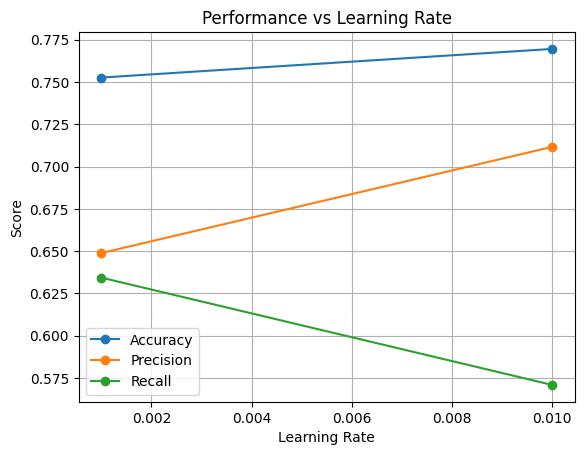

In [ ]:
import matplotlib.pyplot as plt

# Try both learning rates and store results
learning_rates = [0.01, 0.001]
results = {}

for lr in learning_rates:
    weights, bias = train_logistic(X, y, lr=lr, epochs=1000)
    y_pred = predict(X, weights, bias)

    acc, prec, rec = evaluate(y, y_pred)
    results[lr] = (acc, prec, rec)

# Extract values
lrs = list(results.keys())
accuracy = [results[lr][0] for lr in lrs]
precision = [results[lr][1] for lr in lrs]
recall = [results[lr][2] for lr in lrs]

# Plot Accuracy, Precision, Recall
plt.figure()
plt.plot(lrs, accuracy, marker='o', label='Accuracy')
plt.plot(lrs, precision, marker='o', label='Precision')
plt.plot(lrs, recall, marker='o', label='Recall')

plt.xlabel("Learning Rate")
plt.ylabel("Score")
plt.title("Performance vs Learning Rate")
plt.legend()
plt.grid()

plt.show()

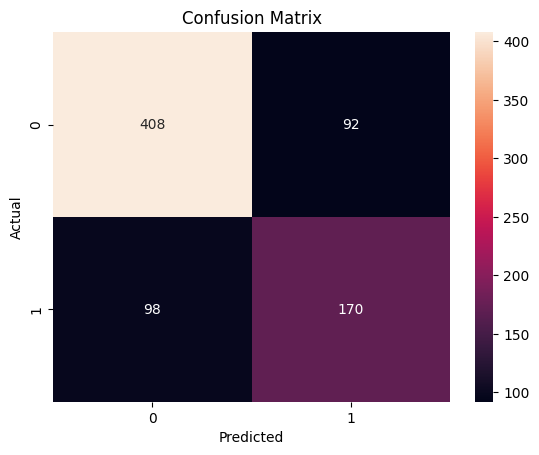

In [ ]:
import seaborn as sns

# Using last model
cm = [[np.sum((y==0)&(y_pred==0)), np.sum((y==0)&(y_pred==1))],
      [np.sum((y==1)&(y_pred==0)), np.sum((y==1)&(y_pred==1))]]

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Conclusion

- Higher learning rate (0.01) converges faster but may overshoot.
- Lower learning rate (0.001) is more stable but slower.
- Choose learning rate based on trade-off between speed and accuracy.
